In [1]:
from forecast import data_reader, forecast_prep, generate_model
from forecast.models import models, models_dict, model_descriptions
from forecast.databases import dbase, dbase_dict, dbase_descriptions
import dateparser
import datetime
import xarray as xr
import matplotlib.pyplot as plt

## Load the GraphCast model information and parameters from disk
`models_dict['era5_100']` is the 1-degree GraphCast model, and `models_dict['era5_025']` is the quarter-degree (ERA5, 37-level) model

In [2]:
mymodel = models_dict['era5_025']
(model_config, task_config, params) = generate_model.load_model(mymodel.path)
predictor = generate_model.build_predictor(model_config,task_config,params,use_gpu=True)

### Select the WeatherBench database used for the forecast
`wb_era5_025_37` is the quarter-degree WeatherBench2 ERA5 dataset with 37 pressure levels.  Precipitation is only given hourly, so forming a full set of forecast inputs requires reading the preceipitation data from 6 one-hour reanalyses.  If the model and database do not share the same grid, the forecaster will interpolate from the database grid to the model grid.

In [3]:
%%time
mydbase = dbase_dict['wb_era5_025_37']
mycachedir = None # 'data_cache'
myreader = data_reader.XArrayReader(mydbase.path,mycachedir,task_config,model_config)

Opening database gs://weatherbench2/datasets/era5/1959-2022-full_37-1h-0p25deg-chunk-1.zarr-v2
CPU times: user 8.21 s, sys: 420 ms, total: 8.63 s
Wall time: 17.9 s


### Select a date and time for the origin of the forecast

In [4]:
mydatestr = "10 October 2020 00:00"
mydate = dateparser.parse(mydatestr)

### Construct the required input and forcing fields
The `4` parameter to forecast_setup specifies a one-day forecast, of four 6h steps.

In [5]:
%%time
(inputs, forcings, targets) = forecast_prep.forecast_setup(mydate,myreader,4)

Reading 20201009T18Z from database
Reading 20201010T00Z from database
Making forcing fields for 20201010T06
Making forcing fields for 20201010T12
Making forcing fields for 20201010T18
Making forcing fields for 20201011T00
CPU times: user 16.8 s, sys: 2.96 s, total: 19.7 s
Wall time: 19.2 s


### Download validation data from the database
This is obviously not required for the forecast itself, but it gives us something to compare to.

In [6]:
%%time
vfields = [];
for i in range(4):
    vdate = mydate + datetime.timedelta(hours=6)*(i+1)
    vf = myreader.readdate(vdate)
    vfields.append(vf)
validation = xr.concat(vfields,'time')
validation = validation.rename({'latitude' : 'lat','longitude' : 'lon'})
validation_gz = validation.geopotential.compute() # Load just the geopotential data

Reading 20201010T06Z from database
Reading 20201010T12Z from database
Reading 20201010T18Z from database
Reading 20201011T00Z from database
CPU times: user 6.31 s, sys: 713 ms, total: 7.03 s
Wall time: 7.97 s


### Make the forecast

The first invocation of predictor() will take 1-2 minutes.  Most of this time is spent with the JIT compilation of the GraphCast neural network, and "compilation is taking a long time" warnings might be output by JAX.

Second and subsequent invocations will take 3-4 seconds on an A100 GPU, even if the forecast date is changed above at 'Select a date and time'.

In [10]:
%%time
predictions = predictor(inputs, targets, forcings)

CPU times: user 1.5 s, sys: 1.27 s, total: 2.77 s
Wall time: 3.55 s


### Plot outputs
* GZ500, prediction only

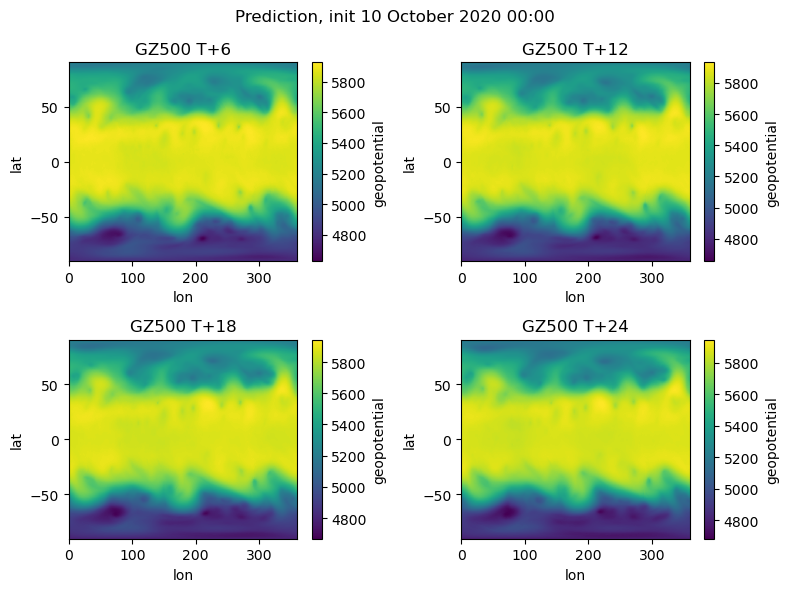

In [11]:
plt.figure(figsize=(8,6))
for idx in range(4):
    plt.subplot(2,2,idx+1)
    ((predictions.geopotential.sel(level=500,drop=True).isel(time=idx,drop=True))/ 9.81).plot()
    plt.title(f'GZ500 T+{6*(1+idx)}')
plt.suptitle(f'Prediction, init {mydatestr}')
plt.gcf().tight_layout()

* GZ500, validation - prediction

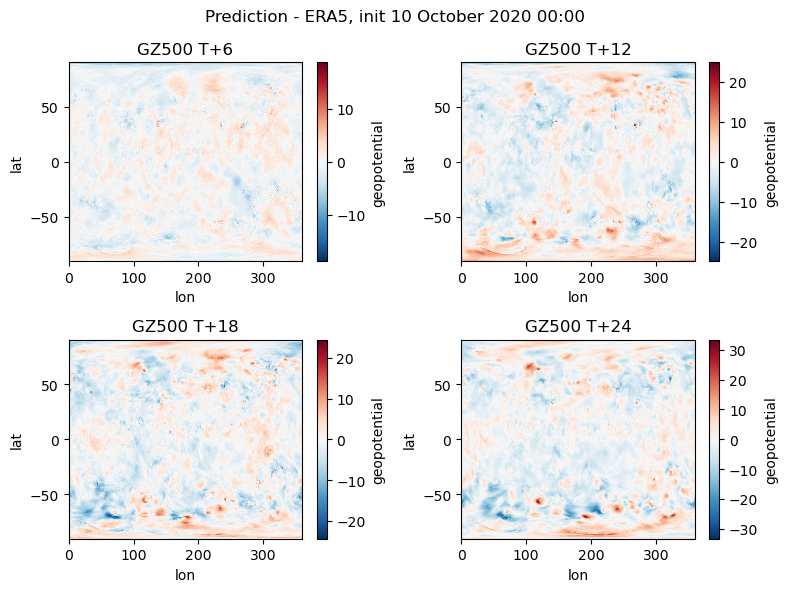

In [12]:
plt.figure(figsize=(8,6))
for idx in range(4):
    plt.subplot(2,2,idx+1)
    ((predictions.geopotential.isel(batch=0,time=idx,drop=True).sel(level=500,drop=True) -\
      validation_gz.sel(level=500,drop=True).isel(time=idx,drop=True))/9.81).plot()
    plt.title(f'GZ500 T+{6*(1+idx)}')
plt.suptitle(f'Prediction - ERA5, init {mydatestr}')
plt.gcf().tight_layout()